# SafePath: Final Report Visuals  
This notebook generates the polished figures used in the SafePath final report, including the crash concentration curve, feature importance plot, HMM regime matrix, and confusion matrix. All figures are produced using preprocessed data and stored model outputs to ensure fast, fully reproducible results.

In [21]:
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import altair as alt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]

DATA_DIR = PROJECT_ROOT / "safepath-dashboard" / "public" / "data"
MODEL_DIR = PROJECT_ROOT / "models" 

FEATURE_IMPORTANCE_PATH = DATA_DIR / "lightgbm_full_panel_with_infra_feature_importance.csv"
CLUSTERS_PATH = DATA_DIR / "segment_clusters_with_infra.csv"
LGB_METRICS_PATH = MODEL_DIR / "lightgbm_full_panel_with_infra_metrics.json"
HMM_MODEL_PATH = MODEL_DIR / "hmm_risk_state_summary.json"

FIGURE_PATH = PROJECT_ROOT / "notebooks" / "figures"


In [22]:
#LGB Metrics & Feature Importance
with open(LGB_METRICS_PATH, "r") as f:
    metrics_json = json.load(f)
feature_importance_df = pd.read_csv(FEATURE_IMPORTANCE_PATH)

#GMM Clusters
clusters_df = pd.read_csv(CLUSTERS_PATH)

#HMM Regimes
with open(HMM_MODEL_PATH, "r") as f:
    hmm_summary = json.load(f)


#### Confusion Matrix Helper Function

In [23]:
# Helper function
def plot_confusion_matrix(cm, title, normalize=False):

    cm = np.array(cm)

    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)

    # annotation logic 
    annot = []
    for row in cm:
        formatted_row = []
        for val in row:
            if not normalize:
                formatted_row.append(f"{int(val)}")
            else:
                if val < 0.01:
                    formatted_row.append("<0.01")
                elif val > 0.99:
                    formatted_row.append(">0.99")
                else:
                    formatted_row.append(f"{val:.2f}")
        formatted_row = formatted_row           
        annot.append(formatted_row)

    ax = sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        linewidths=0.65,
        linecolor="black",
        annot_kws={"size": 14},
        xticklabels=["Pred: No Crash", "Pred: Crash"],
        yticklabels=["Actual: No Crash", "Actual: Crash"],
    )

    for side in ["top", "bottom", "left", "right"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(1.5)

    plt.title(title, weight='bold')


## LightGBM Model Results

## 1. Official Model Performance (Validation + Test)

These metrics come directly from the training pipeline (`metrics.json`) and represent the authoritative evaluation of the LightGBM model.

We report:

- **ROC‑AUC**: ranking quality  
- **Average Precision**: performance under extreme imbalance  
- **Balanced Accuracy**: thresholded performance  
- **F1 Score**: harmonic mean of precision and recall  

The model was trained on 2019–2022, validated on 2023, and tested on 2024.


In [24]:
val_metrics = metrics_json["validation_metrics"]
test_metrics = metrics_json["test_metrics"]

metrics_df = pd.DataFrame([val_metrics, test_metrics], index=["Validation", "Test"])
metrics_df

,threshold,roc_auc,average_precision,balanced_accuracy,f1,confusion_matrix,classification_report
Validation,0.5,0.621619,0.026220,0.590281,0.045741,"[[3440497, 756008], [33537, 18923]]","{'0': {'precision': 0.9903463811810708, 'recal..."
Test,0.5,0.629816,0.025165,0.594836,0.043215,"[[3517056, 697311], [29818, 16421]]","{'0': {'precision': 0.9915931606253845, 'recal..."


## 2. Top‑K Operational Performance

Because crashes are rare events, threshold-based metrics alone do not capture operational usefulness.

We evaluate the model’s ability to identify the highest-risk segment-days:

- **Top‑1%**: highest-risk 1% of predictions  
- **Top‑5%**: highest-risk 5% of predictions  

We report:

- **Precision@K**: proportion of true crashes in the top‑K  
- **Recall@K**: proportion of all crashes captured in the top‑K  
- **Captured Positives**: number of crashes identified  
- **Total Positives**: total crashes in the split  

These metrics are essential for prioritization in the SafePath dashboard.


In [25]:
topk_df = pd.DataFrame([
    {"Split": "Validation", "K": "1%", **metrics_json["validation_top_1pct"]},
    {"Split": "Validation", "K": "5%", **metrics_json["validation_top_5pct"]},
    {"Split": "Test", "K": "1%", **metrics_json["test_top_1pct"]},
    {"Split": "Test", "K": "5%", **metrics_json["test_top_5pct"]},
])

topk_df

,Split,K,top_fraction,k_rows,precision_at_k,captured_positives,total_positives,recall_at_k
0,Validation,1%,0.01,42489,0.062628,2661,52460,0.050724
1,Validation,5%,0.05,212448,0.040203,8541,52460,0.162810
2,Test,1%,0.01,42606,0.061517,2621,46239,0.056684
3,Test,5%,0.05,213030,0.037154,7915,46239,0.171176


## 3. Top‑K Bar Charts

These charts visualize the model’s ability to identify high‑risk segments.

- **Recall@K** shows how many crashes are captured.
- **Precision@K** shows how concentrated the crashes are in the top‑ranked segments.

These visuals support the operational interpretation of the model.


In [26]:
# Make K a categorical with ordering
topk_df["K"] = pd.Categorical(topk_df["K"], categories=["1%", "5%"], ordered=True)

# Recall chart
chart_recall = (
    alt.Chart(topk_df)
    .mark_bar(size=40)  # wider bars
    .encode(
        x=alt.X("K:N", title="Top-K"),
        y=alt.Y("recall_at_k:Q", title="Recall"),
        color=alt.Color("Split:N", legend=alt.Legend(title="Dataset")),
        column=alt.Column("Split:N", title=None)  # separate columns for clarity
    )
    .properties(title="Recall at Top-K (Validation vs Test)", width=120)
)

# Precision chart
chart_precision = (
    alt.Chart(topk_df)
    .mark_bar(size=40)
    .encode(
        x=alt.X("K:N", title="Top-K"),
        y=alt.Y("precision_at_k:Q", title="Precision"),
        color=alt.Color("Split:N", legend=alt.Legend(title="Dataset")),
        column=alt.Column("Split:N", title=None)
    )
    .properties(title="Precision at Top-K (Validation vs Test)", width=120)
)

chart_recall | chart_precision


alt.HConcatChart(...)

#### Isolate Recall

In [27]:
chart_recall = (
    alt.Chart(topk_df)
    .mark_bar(size=40)
    .encode(
        x=alt.X("K:N", title="Top-K"),
        y=alt.Y("recall_at_k:Q", title="Recall"),
        color=alt.Color("Split:N", legend=alt.Legend(title="Dataset")),
        xOffset="Split:N"  # <-- key for grouped bars
    )
    .properties(title="Recall at Top-K (Grouped)", width=300)
)
chart_recall


alt.Chart(...)

## 4. Confusion Matrix (Test Set)

The confusion matrix illustrates the distribution of true positives, false positives, true negatives, and false negatives at the default threshold (0.5).

Because crashes are extremely rare, the matrix is dominated by true negatives.  
The key insight is the balance between false negatives (missed crashes) and false positives (over‑flagged segments).


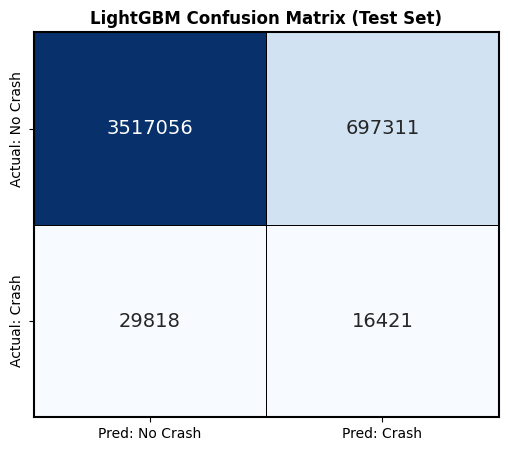

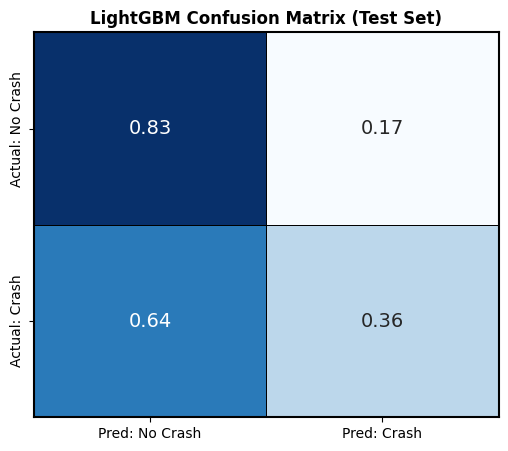

In [28]:
cm = np.array(metrics_json["test_metrics"]["confusion_matrix"])

plt.figure(figsize=(6,5))
plot_confusion_matrix(cm, "LightGBM Confusion Matrix (Test Set)", normalize=False)
plt.show()

plt.figure(figsize=(6,5))
plot_confusion_matrix(cm, "LightGBM Confusion Matrix (Test Set)", normalize=True)
plt.savefig(FIGURE_PATH / "confusion_matrix_final.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Feature Importance

Feature importance values quantify how much each feature contributed to the model’s predictions.

We display the top 15 features to highlight the most influential infrastructure and environmental factors.


In [29]:
# Color Coding Features for chart
color_category = {
    "Weather": "#4e79a7",
    "Temporal": "#f28e2b",
    "Exposure": "#59a14f",
    "Infrastructure": "#9c755f"
}

feature_categories = {
    "temperature_2m_mean": "Weather",
    "windspeed_10m_max": "Weather",
    "precipitation_sum": "Weather",

    "segment_length": "Infrastructure",
    "segment_curvature": "Infrastructure",
    "bearing_change_max": "Infrastructure",
    "visibility_risk_score": "Infrastructure",
    "lanes": "Infrastructure",
    "maxspeed": "Infrastructure",
    "v_degree": "Infrastructure",

    "crashes_last_30_days": "Exposure",

    "day_of_week": "Temporal",
    "month": "Temporal",
    "sin_day_of_week": "Temporal",
    "sin_month": "Temporal",
}


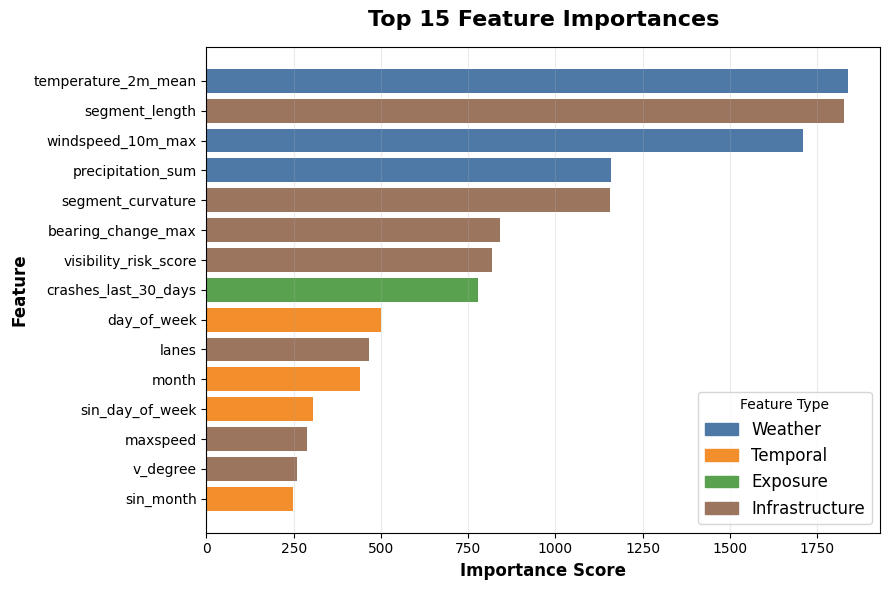

In [10]:
fi = feature_importance_df.sort_values("importance", ascending=False).head(15).iloc[::-1]
fi["category"] = fi["feature"].map(feature_categories)
fi["color"] = fi["category"].map(color_category)

plt.figure(figsize=(9, 6))

plt.barh(
    fi["feature"],
    fi["importance"],
    color=fi["color"],
    edgecolor="none"
)

plt.title("Top 15 Feature Importances", fontsize=16, weight='bold', pad=15)
plt.xlabel("Importance Score", fontsize=12, weight='bold')
plt.ylabel("Feature", fontsize=12, weight='bold')

plt.grid(axis="x", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1, color=color_category[cat])
    for cat in color_category
]
plt.legend(handles, color_category.keys(), title="Feature Type", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURE_PATH / "feature_importance_final.png", dpi=300, bbox_inches="tight")
plt.show()

## Lorenz-Style Crash Concentration Curve 

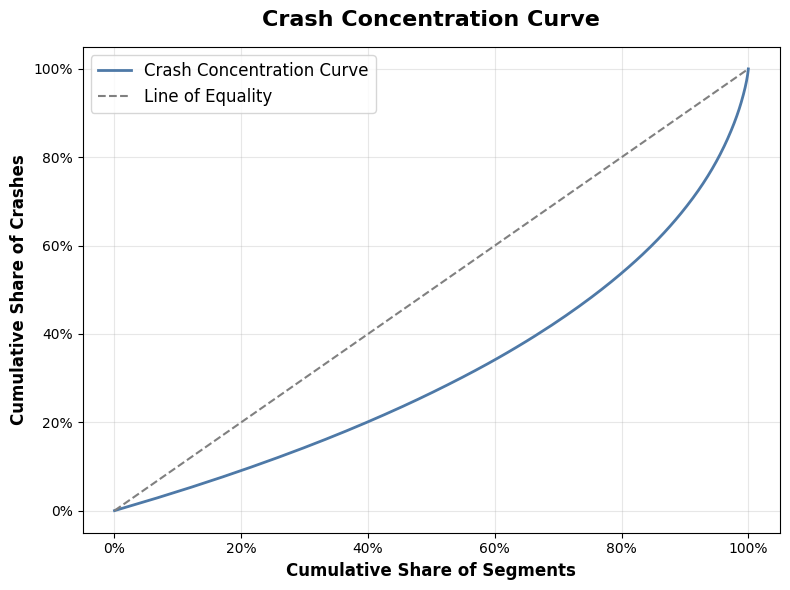

In [11]:
crash_counts = (
    clusters_df[["segment_id", "total_crashes"]]
    .sort_values("total_crashes")
    .reset_index(drop=True)
)

# Shares
crash_counts["cum_segments"] = np.arange(1, len(crash_counts) + 1)
crash_counts["cum_segments_share"] = crash_counts["cum_segments"] / len(crash_counts)

crash_counts["cum_crashes"] = crash_counts["total_crashes"].cumsum()
crash_counts["cum_crashes_share"] = crash_counts["cum_crashes"] / crash_counts["total_crashes"].sum()

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    crash_counts["cum_segments_share"],
    crash_counts["cum_crashes_share"],
    label="Crash Concentration Curve",
    color="#4e79a7",
    linewidth=2
)

# Line of equality
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Line of Equality")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title("Crash Concentration Curve", fontsize=16, weight='bold', pad=15)
plt.xlabel("Cumulative Share of Segments", fontsize=12, weight='bold')
plt.ylabel("Cumulative Share of Crashes", fontsize=12, weight='bold')

plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_PATH / "crash_concentration_final.png", dpi=300, bbox_inches="tight")
plt.show()

# Hidden Markov Model (HMM) Risk States

The HMM identifies latent daily crash-risk regimes based on weather and recent crash activity.  
We summarize:

- Transition probabilities between states  
- State occupancy (how often each regime occurs)  
- Mean feature values for each state  
- Interpretation of the regimes  

These results describe the temporal structure of crash risk across the full study period.


## 1. Transition Matrix

The transition matrix shows the probability of moving from one latent risk state to another on the following day.

High diagonal values indicate persistent regimes.  
Off‑diagonal values indicate transitions between risk levels.


In [12]:
transition_matrix = hmm_summary["transition_matrix"]
state_names = list(hmm_summary["state_counts"].keys())

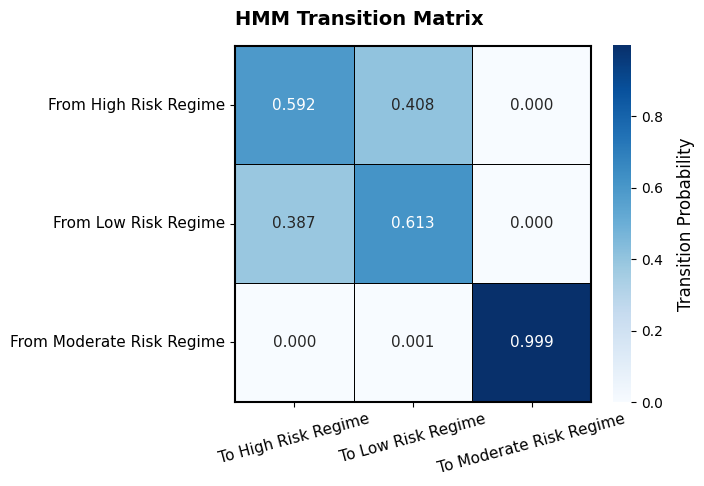

In [13]:
# Transition matrix 
tm = pd.DataFrame(
    transition_matrix,
    index=[f"From {s}" for s in state_names],
    columns=[f"To {s}" for s in state_names]
)

plt.figure(figsize=(7, 6))

ax = sns.heatmap(
    tm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar_kws={"label": "Probability"},
    linewidths=0.65,
    linecolor="black",
    square=True,
    annot_kws={"size": 11}
)


for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1.5)

plt.title("HMM Transition Matrix", fontsize=14, weight="bold",loc="left", pad=15)

plt.xticks(rotation=15, ha="center", fontsize=11)
plt.yticks(rotation=0, fontsize=11)

cbar = ax.collections[0].colorbar
cbar_pos = cbar.ax.get_position()

cbar.ax.set_position([
    cbar_pos.x0,
    cbar_pos.y0 + 1,
    cbar_pos.width,
    cbar_pos.height - .75
])
cbar.set_label("Transition Probability", fontsize=12, labelpad=10)


plt.tight_layout()
plt.savefig(FIGURE_PATH / "hmm_transition_matrix.png", dpi=300, bbox_inches="tight")
plt.show()




## 2. State Occupancy

This chart shows how many days the system spent in each latent risk regime.

This helps interpret which regimes are rare, common, or persistent.


In [14]:
# State counts 
state_counts_df = pd.DataFrame({
    "state": list(hmm_summary["state_counts"].keys()),
    "count": list(hmm_summary["state_counts"].values())
})

state_counts_chart = (
    alt.Chart(state_counts_df)
    .mark_bar()
    .encode(
        x=alt.X("state:N", title="State"),
        y=alt.Y("count:Q", title="Days in State"),
        tooltip=["state", "count"]
    )
    .properties(width=300, height=300, title="State Occupancy")
)

state_counts_chart


alt.Chart(...)

## 3. State Feature Profiles

Each HMM state has characteristic average values for:

- Crash rate  
- Recent crash history  
- Weather conditions  

These profiles help interpret the regimes as **Low‑Risk**, **Moderate‑Risk**, or **High‑Risk** states.

In [15]:
# State means summary
state_means_df = pd.DataFrame(hmm_summary["state_means"])
state_means_df

,state_label,total_crashes,crash_rate,avg_crashes_last_7_days,avg_crashes_last_30_days,temperature_2m_mean,precipitation_sum,windspeed_10m_max,rain_indicator
0,High Risk Regime,350.711353,0.028837,0.210678,0.898532,11.250121,4.065338,21.892754,0.586957
1,Low Risk Regime,149.224099,0.012569,0.090448,0.388751,14.514527,7.410473,22.571284,1.000000
2,Moderate Risk Regime,150.105826,0.012651,0.089451,0.382942,12.016052,0.000000,20.262663,0.000000


## 4. Interpreting the Three HMM Risk Regimes

The Hidden Markov Model identifies three latent daily “risk regimes” in NYC, each defined by characteristic patterns of weather and recent crash activity. These regimes represent underlying traffic–weather conditions that the city transitions between over time.

The table above summarizes the mean values for each state.

---

### **1. High Risk Regime — Elevated Crashes During Wet, Windy Conditions**

This regime exhibits the **highest crash counts and crash rates** across all states. Days in this regime typically show:

- Moderate precipitation (~4 mm)  
- Rain on ~59% of days  
- Elevated wind speeds (~22 km/h)  
- Cooler temperatures (~11°C)  
- Higher recent crash averages (7‑day and 30‑day)

These conditions reflect **unstable weather with normal traffic volume**, producing slick roads, reduced visibility, and increased braking distances. The combination of active weather and typical congestion levels leads to **heightened crash risk**.

---

### **2. Low Risk Regime — Heavy Rain but Low Crash Activity**

Despite having the **heaviest precipitation** (~7.4 mm) and a rain indicator of **1.0** (rain every day), this state shows **low crash counts and low crash rates**.

This counterintuitive pattern likely reflects:

- Reduced traffic volume  
- Slower driving speeds  
- Trip cancellations  
- Off‑peak or weekend periods  

This regime represents **“rain but low exposure”** conditions — weather is more severe, but fewer vehicles are on the road, reducing overall crash risk.

---

### **3. Moderate Risk Regime — Dry, Normal Traffic Conditions**

This regime represents the city’s **baseline state**, with:

- **Zero precipitation**  
- Rain indicator of 0  
- Moderate temperatures (~12°C)  
- Lowest wind speeds among the three regimes  
- Crash rates similar to the Low Risk regime  

The transition matrix shows this regime is extremely stable (≈99.9% self‑transition), indicating that NYC spends most of its time in this default dry‑weather condition.

---


In [16]:
# Melt for Altair
melted = state_means_df.melt(id_vars="state_label", var_name="feature", value_name="value")

# Select features to visualize
features_to_plot = [
    "crash_rate",
    "precipitation_sum",
    "avg_crashes_last_7_days",
    "avg_crashes_last_30_days",
    "windspeed_10m_max"
]

charts = []
for feat in features_to_plot:
    chart = (
        alt.Chart(melted[melted["feature"] == feat])
        .mark_bar()
        .encode(
            x=alt.X("state_label:N", title="State"),
            y=alt.Y("value:Q", title=feat),
            tooltip=["state_label", "value"]
        )
        .properties(width=200, height=250, title=feat)
    )
    charts.append(chart)

# Combine horizontally
charts[0] | charts[1] | charts[2] | charts[3] | charts[4]


alt.HConcatChart(...)

# Gaussian Mixture Model (GMM) Segment Clusters

The GMM groups NYC street segments into latent infrastructure–risk clusters based on roadway geometry and built environment features. These clusters represent **structural risk profiles** that remain stable over time and help contextualize the LightGBM predictions.

We summarize:

- Cluster sizes and crash rates  
- Infrastructure characteristics of each cluster  
- Visual comparisons of cluster profiles  
- Interpretation of the cluster types  

These results describe the *static* risk landscape of NYC’s street network.


## 1. Cluster Summary Table

Each cluster represents a distinct type of street segment, defined by infrastructure features such as curvature, visibility, and intersection density.

We report:

- Number of segment-days  
- Crash rate  
- Mean curvature  
- Mean visibility score  
- Mean intersection density  

This table provides the foundation for interpreting the clusters.


In [17]:
clusters_df.columns

Index(['segment_id', 'total_crashes', 'avg_crash_rate', 'crash_volatility',
       'pct_days_with_crash', 'avg_crashes_last_7_days',
       'avg_crashes_last_30_days', 'segment_length', 'road_type', 'lanes',
       'maxspeed', 'oneway', 'is_bridge', 'is_tunnel', 'is_junction',
       'segment_curvature', 'bearing_change_max', 'u_degree', 'v_degree',
       'intersection_degree_max', 'near_intersection', 'near_traffic_signal',
       'near_crossing', 'curvature_norm', 'bearing_norm', 'intersection_norm',
       'visibility_risk_score', 'gmm_cluster', 'cluster_probability_max',
       'cluster_label'],
      dtype='str')

In [18]:
cluster_col = "gmm_cluster" 

cluster_summary = clusters_df.groupby(cluster_col).agg(
    n_segments=("segment_id", "count"),
    total_crashes=("total_crashes", "mean"),
    avg_crash_rate=("avg_crash_rate", "mean"),
    crash_volatility=("crash_volatility", "mean"),
    pct_days_with_crash=("pct_days_with_crash", "mean"),
    curvature=("segment_curvature", "mean"),
    visibility=("visibility_risk_score", "mean"),
    intersections=("intersection_degree_max", "mean")
).reset_index().rename(columns={cluster_col: "cluster"})

cluster_summary


,cluster,n_segments,total_crashes,avg_crash_rate,crash_volatility,pct_days_with_crash,curvature,visibility,intersections
0,0,1526,44.705111,0.017062,0.124148,0.017062,0.018813,0.150028,4.354522
1,1,340,121.626471,0.043176,0.178647,0.043176,0.282470,0.163078,3.720588
2,2,2606,32.922487,0.012680,0.110159,0.012680,0.000041,0.114534,3.945894
3,3,5343,44.676961,0.017079,0.124274,0.017079,0.000036,0.115986,4.000000
4,4,1826,63.012596,0.023516,0.139281,0.023516,0.009124,0.093679,3.000000


## 2. Crash Rate by Cluster

Crash rates vary substantially across clusters, reflecting differences in roadway geometry and exposure.

This bar chart highlights which clusters represent the highest structural crash risk.


In [19]:
alt.Chart(cluster_summary).mark_bar().encode(
    x=alt.X("cluster:N", title="Cluster"),
    y=alt.Y("avg_crash_rate:Q", title="Average Crash Rate"),
    tooltip=["cluster", "avg_crash_rate"]
).properties(
    width=300,
    height=300,
    title="Average Crash Rate by GMM Cluster"
)

alt.Chart(...)

## 3. Infrastructure Profiles by Cluster

To understand what differentiates the clusters, we compare their average values for key infrastructure features:

- Segment curvature  
- Visibility risk score  
- Intersection density  

These features capture geometric and environmental conditions that influence crash likelihood.


In [20]:
infra_cols = ["segment_curvature", "visibility_risk_score", "intersection_degree_max"]

cluster_means = clusters_df.groupby("gmm_cluster")[infra_cols].mean().reset_index()
cluster_means = cluster_means.rename(columns={"gmm_cluster": "cluster"})

melted = cluster_means.melt(id_vars="cluster", var_name="feature", value_name="value")

alt.Chart(melted).mark_bar().encode(
    x=alt.X("feature:N", title="Feature"),
    y=alt.Y("value:Q", title="Mean Value"),
    color="cluster:N",
    column=alt.Column("cluster:N", title="Cluster")
).properties(
    width=150,
    height=250,
    title="Infrastructure Profiles by Cluster"
)


alt.Chart(...)

## 4. Interpreting the GMM Clusters

The Gaussian Mixture Model identifies five distinct infrastructure–risk clusters across NYC’s street network. These clusters reflect structural differences in roadway geometry, visibility, and intersection complexity that shape long‑term crash risk.

The table below summarizes key characteristics of each cluster.

---

### **Cluster 1 — High-Risk Curved Segments (Small but Dangerous)**  
**(340 segments, highest crash rate: 0.0432)**

This is the **highest‑risk cluster** despite being the smallest. It is defined by:

- **Highest curvature** (0.282)  
- **High visibility risk** (0.163)  
- **Moderately high intersection density** (3.72)  
- **Highest crash volatility** (0.1786)  
- **Highest pct_days_with_crash** (0.0432)

These segments likely represent **curved approaches, complex turns, or visually constrained environments** where geometry directly contributes to elevated crash risk.

---

### **Cluster 4 — Elevated-Risk Straight Segments (Moderate Size)**  
**(1,826 segments, crash rate: 0.0235)**

This cluster shows:

- **Moderate curvature** (0.009)  
- **Lower visibility risk** (0.094)  
- **Lowest intersection density** (3.00)  
- **Moderate crash volatility** (0.139)

These are typically **straight, mid‑sized arterials** where risk is driven more by **speed and exposure** than geometry.

---

### **Cluster 0 — Moderate-Risk Residential/Collector Segments**  
**(1,526 segments, crash rate: 0.0171)**

This cluster has:

- **Low curvature** (0.019)  
- **Moderate visibility risk** (0.150)  
- **High intersection density** (4.35)  
- **Moderate crash volatility** (0.124)

These segments resemble **residential collectors** with frequent intersections and moderate sightline constraints.

---

### **Cluster 3 — Low-Risk High-Exposure Baseline Segments**  
**(5,343 segments, crash rate: 0.0171)**

This is the **largest cluster** and represents NYC’s **baseline street type**:

- **Near-zero curvature**  
- **Moderate visibility risk**  
- **High intersection density** (4.00)  
- **Moderate crash volatility**

These are **straight, typical city streets** with normal traffic patterns and average risk.

---

### **Cluster 2 — Lowest-Risk Straight Segments**  
**(2,606 segments, lowest crash rate: 0.0127)**

This cluster shows:

- **Near-zero curvature**  
- **Low visibility risk**  
- **Moderate intersection density**  
- **Lowest crash volatility**

These are **straight, predictable segments** with good sightlines and fewer geometric hazards.

---

### **Summary**

The GMM clusters reveal a clear structural risk gradient:

- **Cluster 1** is the standout high‑risk group, driven by **curvature + visibility constraints**.  
- **Cluster 4** is elevated risk due to **exposure and speed**, not geometry.  
- **Clusters 0 and 3** represent **moderate, typical city streets**.  
- **Cluster 2** is the **safest**, with clean geometry and low volatility.

These clusters provide a stable, infrastructure‑driven risk baseline that complements the LightGBM model’s dynamic predictions.
